In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

In [2]:
df_rmse = xr.open_dataset("/appl/Hainich/Tests/Sens_Output0_adpated_200000.nc").to_dataframe()
df_rmse

,RMSE_J,RMSE_G,RMSE_psi_stem
run_id,,,
0,0.000718,0.000829,1.196328
1,0.000470,0.000771,1.896129
2,0.001238,0.001396,2.679399
3,0.000853,0.001048,1.403475
4,0.001645,0.001777,3.043082
...,...,...,...
99995,0.001414,0.001692,1.166034
99996,0.001424,0.001563,3.662659
99997,0.001194,0.001472,1.110591


In [3]:
df_s = pd.read_csv("/Users/pp/Documents/Repos/plant_hydro_standalone/py/appl/LHS/generator_files/Hainich_parameters_100000.csv")

In [6]:
df_s['psi_soil_sat0'] = df_s['psi_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['k_soil_sat0'] = df_s['k_soil_sats'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_s0'] = df_s['theta_s'].str.split(';', expand=True).values[:,0].astype(float)
df_s['theta_r0'] = df_s['theta_r'].str.split(';', expand=True).values[:,0].astype(float)
df_s['pore_0'] = df_s['pore_size_ind'].str.split(';', expand=True).values[:,0].astype(float)

In [7]:
df_d = pd.concat([df_s, df_rmse], axis=1)

In [8]:
df_d

,Unnamed: 0,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,sw_rad_max,...,theta_emp_multiplier,solver_precision,psi_soil_sat0,k_soil_sat0,theta_s0,theta_r0,pore_0,RMSE_J,RMSE_G,RMSE_psi_stem
0,0,0,1800.0,1800,False,1.0,4.0,Weibull,2.595431,972.935,...,1.0,1.000000e-10,-0.008945,1.043853e-07,0.488031,0.070516,0.539996,0.000718,0.000829,1.196328
1,1,1,1800.0,1800,False,1.0,4.0,Weibull,2.868848,972.935,...,1.0,1.000000e-10,-0.001088,1.875128e-08,0.491112,0.052363,0.497190,0.000470,0.000771,1.896129
2,2,2,1800.0,1800,False,1.0,4.0,Weibull,2.754410,972.935,...,1.0,1.000000e-10,-0.003130,4.006381e-08,0.465973,0.111517,0.574520,0.001238,0.001396,2.679399
3,3,3,1800.0,1800,False,1.0,4.0,Weibull,2.165156,972.935,...,1.0,1.000000e-10,-0.007062,4.147439e-07,0.491688,0.100561,0.531593,0.000853,0.001048,1.403475
4,4,4,1800.0,1800,False,1.0,4.0,Weibull,2.492310,972.935,...,1.0,1.000000e-10,-0.001066,2.954666e-08,0.481075,0.076303,0.587673,0.001645,0.001777,3.043082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,99995,1800.0,1800,False,1.0,4.0,Weibull,2.736657,972.935,...,1.0,1.000000e-10,-0.003601,7.892944e-07,0.479005,0.100884,0.492295,0.001414,0.001692,1.166034
99996,99996,99996,1800.0,1800,False,1.0,4.0,Weibull,2.595967,972.935,...,1.0,1.000000e-10,-0.002821,8.213455e-08,0.495449,0.115656,0.558656,0.001424,0.001563,3.662659
99997,99997,99997,1800.0,1800,False,1.0,4.0,Weibull,3.714516,972.935,...,1.0,1.000000e-10,-0.006415,9.942855e-08,0.452887,0.103438,0.559834,0.001194,0.001472,1.110591
99998,99998,99998,1800.0,1800,False,1.0,4.0,Weibull,2.450661,972.935,...,1.0,1.000000e-10,-0.003910,2.685857e-07,0.477204,0.091966,0.596754,0.000932,0.001104,0.313415


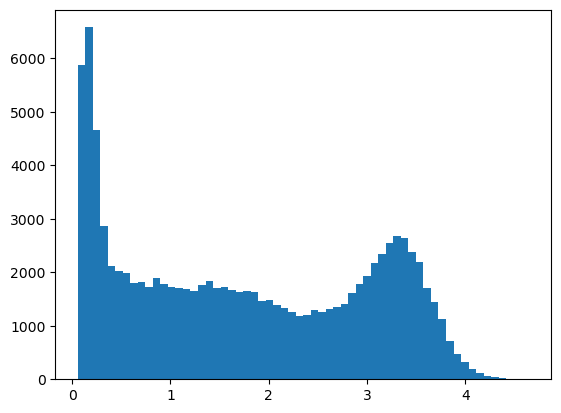

In [12]:
plt.hist(df_d['RMSE_psi_stem'], bins =60);

In [41]:
df_psi_stem = df_d.loc[df_d['RMSE_psi_stem'] < 0.075]
print(df_psi_stem.shape)

(311, 51)


In [42]:
df_J= df_d.loc[df_d['RMSE_J'] < 0.00041]
print(df_psi_stem.shape)

(311, 51)


Text(0.5, 1.0, 'pore_0')

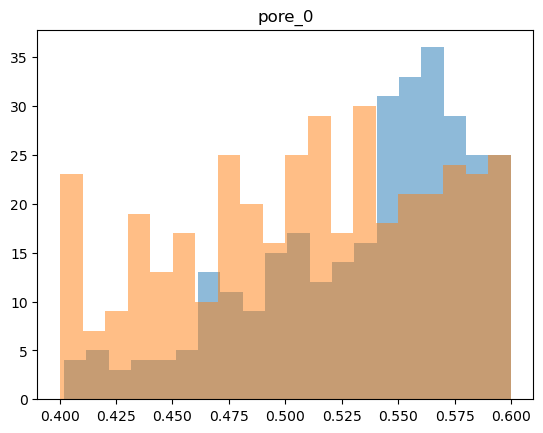

In [43]:
plt.hist(df_psi_stem['pore_0'], alpha = 0.5, bins = 20);
plt.hist(df_J['pore_0'], alpha = 0.5, bins = 20);
plt.title("pore_0")

In [61]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem','leaf_area_index', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta', 'theta_s0', 'pore_0', 'theta_r0', 'anet_max', 'root_area_index', 'tree_density' ]

for var in vars:
    
    if var == 'leaf_hydraulic_capacitance':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    elif var == 'k_soil_sat0':
        plt.hist(np.log10(df_psi_stem[var]), alpha = 0.5, bins = 20);
        plt.hist(np.log10(df_J[var]), alpha = 0.5, bins = 20);
    else:
        plt.hist(df_psi_stem[var], alpha = 0.5, bins = 20);
        plt.hist(df_J[var], alpha = 0.5, bins = 20);

    plt.title(var)
    plt.savefig(f"out/{var}.png")
    plt.close()

In [47]:
df_J.index

Index([  646,  1365,  1670,  1700,  2210,  2347,  2422,  2925,  3084,  3316,
       ...
       97618, 97917, 97938, 98162, 98618, 98758, 99263, 99420, 99799, 99847],
      dtype='int64', length=392)

In [51]:
df_psi_stem.index

Index([  102,   174,   866,  1552,  2628,  2706,  3115,  6198,  6659,  6705,
       ...
       95871, 95974, 96282, 96798, 96831, 96851, 97104, 98035, 98362, 99266],
      dtype='int64', length=311)

In [52]:
np.intersect1d(df_psi_stem.index, df_J.index)

array([56405])

In [55]:
df_d.iloc[56405]

Unnamed: 0                                                             56405
id                                                                     56405
dts                                                                   1800.0
dts_input                                                               1800
verbose                                                                False
max_psi_leaf_change_per_hour                                             1.0
minimum_psi_leaf_multiplier                                              4.0
conductivity_fraction_type                                           Weibull
anet_max                                                            3.345399
sw_rad_max                                                           972.935
sustain_xylem_damage                                                   False
root_area_index                                                     2.420284
canopy_height                                                             31